# Toda Oszillator

In [1]:
#imports
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares
from scipy.integrate import trapezoid

## Kapazität der Diode
Die Resonanzfrequenz im Serienschwingkreis ist $\omega_0=1/\sqrt{LC}$. Wenn wir also die Resonanzfrequenz messen, können wir die Kapazität bestimmen.

In [2]:
# Messwertetabelle (aus dem eLab) 
reso_freq = {
    # Uoff in V : f in Hz
    -0.70 : 73.1e3,
    -0.63 : 72.3e3,
    -0.56 : 71.6e3,
    -0.49 : 70.7e3,
    -0.42 : 69.7e3,
    -0.35 : 68.8e3,
    -0.28 : 67.6e3,
    -0.21 : 66.5e3,
    -0.14 : 65.1e3,
    -0.07 : 63.6e3,
     0.00 : 61.8e3,
     0.03 : 61.0e3,
     0.06 : 60.0e3,
     0.09 : 59.0e3,
     0.12 : 57.9e3,
     0.15 : 56.5e3,
     0.18 : 54.8e3,
     0.21 : 52.4e3,
     0.24 : 48.2e3,
     0.27 : 40.1e3,
     0.30 : 24.9e3
}


C0 = 100e-12 # 100 pF

def Kapazität(Frequenz: np.ndarray) -> np.ndarray:
    L = 64e-3 # 64 mH
    C = []
    for freq in Frequenz:
        C.append(1/(L*freq*freq*4*np.pi*np.pi)) # 2 pi f = w
    return np.array(C) # Kapazität in F

[  23.9657247  -313.31849748   74.28190107] 2.114323440728471e-05


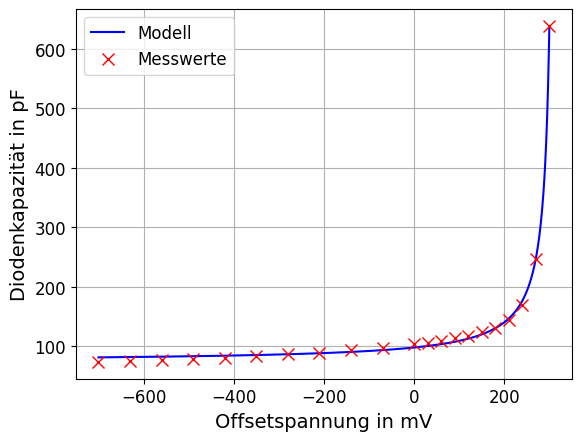

In [3]:
# Messwertelisten
Spannung = np.array(list(reso_freq))*1e3
Frequenz = np.array(list(reso_freq.values()))
Kapa = Kapazität(Frequenz)*1e12

# Fitten
def residuen_skript(coeff, U, C):
    c0, Us, o = coeff
    return C - (c0*Us)/(Us + U) - o

guess_skript = [100, -500, 50]

fit_skript = least_squares(residuen_skript, guess_skript, args=(Spannung, Kapa), method='lm')

Parameter_skript = fit_skript.x

print(Parameter_skript, fit_skript.optimality)
c0, Us, o = Parameter_skript

kontinuierlich = np.arange(min(Spannung), max(Spannung)+1)
modell_skript = (c0*Us)/(Us + kontinuierlich) + o

# plotting
fig, ax = plt.subplots()
ax.plot(kontinuierlich, modell_skript, "b", label="Modell")
ax.plot(Spannung, Kapa, "xr", label="Messwerte", ms=9)
ax.tick_params(axis="both", labelsize=12)
ax.set_xlabel("Offsetspannung in mV", fontsize=14)
ax.set_ylabel("Diodenkapazität in pF", fontsize=14)
ax.grid()
ax.legend(fontsize=12)
plt.show()

[ 9.70287823e+01  2.83387399e+02 -1.55263349e+05] 232.60528065477797


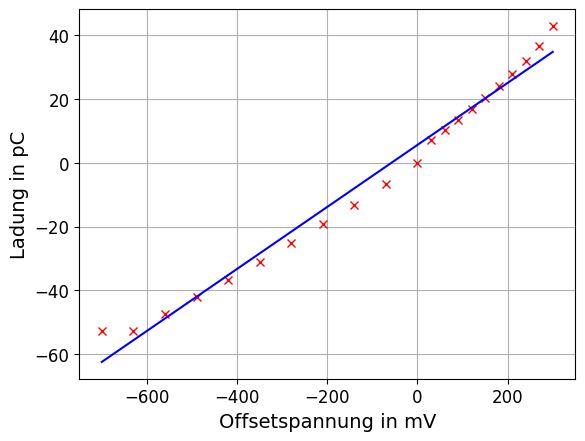

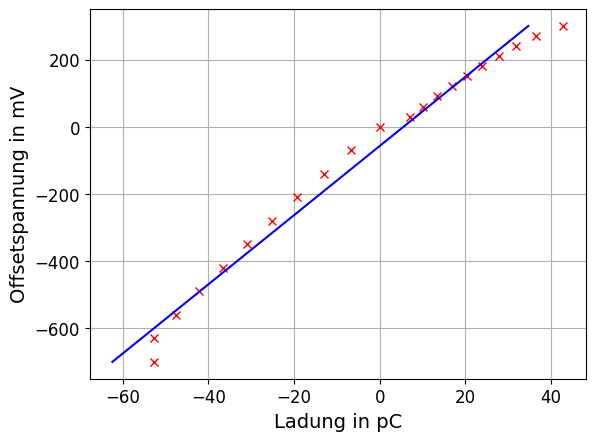

In [23]:
# erste Integration
Spannung = np.array(list(reso_freq))
Kapa = Kapazität(Frequenz)*1e12

Ladung = []

for i in range(len(Spannung)):
    Ladung.append(trapezoid(Kapa[:i], Spannung[:i]))

Ladung = np.array(Ladung)-Ladung[10]

# Fitten
def residuen_ladung(coeff, Q, U):
    c0, Us, o = coeff
    return Q - ((c0*Us)*np.log(Us+U)+o)

guess_ladung = [100, 300, 0]

fit_ladung = least_squares(residuen_ladung, guess_ladung, args=(Ladung, Spannung), method='lm')
Parameter_ladung = fit_ladung.x

print(Parameter_ladung, fit_ladung.optimality)
c0, Us, o = Parameter_ladung

kontinuierlich = np.arange(min(Spannung), max(Spannung)+1)
modell_ladung = (c0*Us)*np.log(Us+kontinuierlich)+o


# ax1
fig, ax1 = plt.subplots()
ax1.plot(Spannung*1e3, Ladung, "xr")
ax1.plot(kontinuierlich*1e3, modell_ladung, "b")
ax1.grid()
ax1.tick_params(axis="both", labelsize=12)
ax1.set_xlabel("Offsetspannung in mV", fontsize=14)
ax1.set_ylabel("Ladung in pC", fontsize=14)
# ax2
fig, ax2 = plt.subplots()
ax2.plot(Ladung, Spannung*1e3, "xr")
ax2.plot(modell_ladung, kontinuierlich*1e3, "b")
ax2.grid()
ax2.tick_params(axis="both", labelsize=12)
ax2.set_ylabel("Offsetspannung in mV", fontsize=14)
ax2.set_xlabel("Ladung in pC", fontsize=14)
plt.show()

[-0.7  -0.63 -0.56 -0.49 -0.42 -0.35 -0.28 -0.21 -0.14 -0.07  0.    0.03
  0.06  0.09  0.12  0.15  0.18  0.21  0.24  0.27  0.3 ]
[7.40671332e-11 7.57153082e-11 7.72030121e-11 7.91810874e-11
 8.14694404e-11 8.36148496e-11 8.66097724e-11 8.94987560e-11
 9.33895563e-11 9.78466718e-11 1.03629485e-10 1.06365459e-10
 1.09940520e-10 1.13698901e-10 1.18060104e-10 1.23983358e-10
 1.31795072e-10 1.44144380e-10 1.70359444e-10 2.46133963e-10
 6.38354016e-10]
[15.84905022 15.84905022 15.84905022 12.72983088  9.91995674  7.42953996
  5.26477409  3.4447198   1.98504366  0.90637893  0.23426438  0.
  0.10577498  0.24752157  0.4908658   0.84309788  1.31240987  1.91146744
  2.65961935  3.590915    4.79389212]
[-52.68470794 -52.68470794 -47.44232249 -42.09018128 -36.6167378
 -30.99396933 -25.21601918 -19.25815741 -13.09435892  -6.69326798
   0.           7.05166548  10.20158964  13.44617934  16.80077065
  20.27715573  23.90780765  27.7444841   31.88357589  36.60113325
  42.84853434]
[-2.85793270e+05  1.14

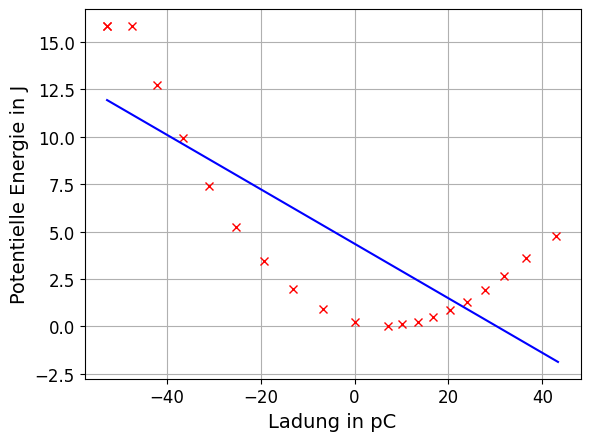

In [ ]:
# zweite Integration
Spannung = np.array(list(reso_freq)) # V
Kapa = Kapazität(Frequenz) # pF
V = []

for i in range(len(Spannung)):
    V.append(trapezoid(Spannung[:i], Ladung[:i]))

V = np.array(V)-min(V) # 

print(Spannung)
print(Kapa)
print(V)
print(Ladung)

# Fitten
def residuen_potential(coeff, Q, V):
    c0, Us, o = coeff
    return V - ((c0*Us)*np.exp(Q/c0/Us)-Us*Q-o)

guess_potential = [100, 300, 0]

fit_potential = least_squares(residuen_potential, guess_potential, args=(Ladung, V), method='lm')
Parameter_potential = fit_potential.x

print(Parameter_potential, fit_potential.optimality)
c0, Us, o = Parameter_potential

kont_lad = np.arange(min(Ladung), max(Ladung)+1)
modell_potential = ((c0*Us)*np.exp(kont_lad/c0/Us)-Us*kont_lad-o)

# plotten
fig, ax = plt.subplots()
ax.plot(Ladung, V, "xr")
ax.plot(kont_lad, modell_potential, "b")
ax.grid()
ax.tick_params(axis="both", labelsize=12)
ax.set_xlabel("Ladung in pC", fontsize=14)
ax.set_ylabel("Potentielle Energie in J", fontsize=14)
plt.show()